### Imports & Global Config

In [2]:
import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

### Model Architecture

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import math, os, sys

def _safe_install(package):
    import subprocess
    result = subprocess.run([sys.executable, '-m', 'pip', 'install', package, '-q'],
                            capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(f'Failed to install {package}:\n{result.stderr}')

try:
    import mdtraj as md
except ImportError:
    _safe_install('mdtraj'); import mdtraj as md

try:
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import f1_score
except ImportError:
    _safe_install('scikit-learn')
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import f1_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

N_CA          = 341
N_BONDS       = N_CA - 1
N_ANGLES      = N_CA - 2
N_DIHEDRALS   = N_CA - 3
INPUT_DIM     = N_BONDS + N_ANGLES + 2 * N_DIHEDRALS

LATENT_DIM    = 64
N_CLASSES     = 2
LABEL_EMB_DIM = 8

CA_BOND_A    = 3.8
CA_BOND_TOL  = 0.3
CONTACT_THR  = 8.0

EPS = 1e-8

DRIVE      = '/content/drive/MyDrive'
OPEN_PDB   = f'{DRIVE}/trainca_open.pdb'
CLOSED_PDB = f'{DRIVE}/trainca_close.pdb'
CKPT_PATH  = f'{DRIVE}/cvae_best_v5.pt'

def clamp_bonds(bonds: torch.Tensor) -> torch.Tensor:
    return torch.clamp(bonds, CA_BOND_A - CA_BOND_TOL, CA_BOND_A + CA_BOND_TOL)

print(f'INPUT_DIM={INPUT_DIM}  LATENT_DIM={LATENT_DIM}  N_CLASSES={N_CLASSES}')
print('✅ Cell 1 complete')

Device: cpu
INPUT_DIM=1355  LATENT_DIM=64  N_CLASSES=2
✅ Cell 1 complete


### Data Loading & Preprocessing

In [4]:
def parse_pdb_models(pdb_path: str) -> np.ndarray:
    traj   = md.load(pdb_path)
    ca_idx = traj.topology.select('name CA')
    return (traj.atom_slice(ca_idx).xyz * 10.0).astype(np.float32)


def kabsch_align_np(reference: np.ndarray, mobile: np.ndarray) -> np.ndarray:
    ref_c    = reference - reference.mean(axis=0)
    mobile_c = mobile    - mobile.mean(axis=0)
    C        = mobile_c.T @ ref_c
    V, S, Wt = np.linalg.svd(C)
    d        = np.sign(np.linalg.det(V @ Wt))
    D        = np.diag([1.0, 1.0, d])
    U        = V @ D @ Wt
    return mobile_c @ U


def find_medoid(frames: np.ndarray) -> tuple:
    mean_s = frames.mean(axis=0)
    mean_s -= mean_s.mean(axis=0)
    rmsds  = []
    for f in frames:
        fc = f - f.mean(axis=0)
        rmsds.append(np.sqrt(np.mean(np.sum((fc - mean_s) ** 2, axis=1))))
    idx = int(np.argmin(rmsds))
    print(f'    Medoid #{idx}  RMSD-to-mean: {rmsds[idx]:.3f} Å  (worst: {max(rmsds):.3f} Å)')
    return frames[idx], idx


def align_all_to_ref(frames: np.ndarray, reference: np.ndarray) -> np.ndarray:
    return np.array([kabsch_align_np(reference, f) for f in frames], dtype=np.float32)


open_data   = parse_pdb_models(OPEN_PDB)
closed_data = parse_pdb_models(CLOSED_PDB)
print(f'Open   frames: {open_data.shape}')
print(f'Closed frames: {closed_data.shape}')
assert open_data.shape[1:] == closed_data.shape[1:]
assert not np.isnan(open_data).any() and not np.isnan(closed_data).any()

print('Finding global reference...')
global_ref, global_ref_idx = find_medoid(open_data)
global_ref = global_ref - global_ref.mean(axis=0)

print('Aligning open frames...')
open_aligned   = align_all_to_ref(open_data,   global_ref)
print('Aligning closed frames...')
closed_aligned = align_all_to_ref(closed_data, global_ref)

coords_all = np.concatenate([open_aligned, closed_aligned], axis=0)
labels     = np.array([0]*len(open_aligned) + [1]*len(closed_aligned), dtype=np.int32)

full_traj   = md.load(OPEN_PDB)
ca_idx      = full_traj.topology.select('name CA')
ca_topology = full_traj.atom_slice(ca_idx).topology

print(f'\ncoords_all: {coords_all.shape}  labels: {labels.shape}')

Open   frames: (1896, 341, 3)
Closed frames: (1921, 341, 3)
Finding global reference...
    Medoid #1150  RMSD-to-mean: 1.867 Å  (worst: 10.521 Å)
Aligning open frames...
Aligning closed frames...

coords_all: (3817, 341, 3)  labels: (3817,)


### Internal Coordinate Functions

In [5]:
def compute_bonds(ca: np.ndarray) -> np.ndarray:
    return np.linalg.norm(ca[1:] - ca[:-1], axis=1)


def compute_angles(ca: np.ndarray) -> np.ndarray:

    v1 = ca[:-2] - ca[1:-1]
    v2 = ca[2:]  - ca[1:-1]
    v1 = v1 / (np.linalg.norm(v1, axis=1, keepdims=True) + EPS)
    v2 = v2 / (np.linalg.norm(v2, axis=1, keepdims=True) + EPS)
    return np.arccos(np.clip((v1 * v2).sum(axis=1), -1.0, 1.0))


def _mdtraj_topology_for(n_ca: int) -> md.Topology:
    top   = md.Topology()
    chain = top.add_chain()
    for _ in range(n_ca):
        res = top.add_residue('GLY', chain)
        top.add_atom('CA', md.element.carbon, res)
    return top


def compute_dihedrals_batch(all_ca: np.ndarray) -> np.ndarray:
    n_frames, n_ca, _ = all_ca.shape
    top      = _mdtraj_topology_for(n_ca)
    traj     = md.Trajectory(all_ca / 10.0, top)
    quartets = np.array([[i, i+1, i+2, i+3] for i in range(n_ca - 3)])
    return md.compute_dihedrals(traj, quartets)


print('Extracting internal coordinates...')
bonds_raw  = np.array([compute_bonds(f)  for f in coords_all])
angles_raw = np.array([compute_angles(f) for f in coords_all])
dihedrals  = compute_dihedrals_batch(coords_all)

nan_frames = np.where(np.isnan(dihedrals).any(axis=1))[0]
if len(nan_frames) > 0:
    print(f'    NaN dihedrals in {len(nan_frames)} frames — replacing with 0.0')
    dihedrals = np.nan_to_num(dihedrals, nan=0.0)
else:
    print('  No NaN dihedrals')

assert not np.isnan(bonds_raw).any()
assert not np.isnan(angles_raw).any()
assert not np.isnan(dihedrals).any()

bonds  = bonds_raw
angles = angles_raw
print(f'bonds:{bonds.shape}  angles:{angles.shape}  dihedrals:{dihedrals.shape}')

Extracting internal coordinates...
  No NaN dihedrals
bonds:(3817, 340)  angles:(3817, 339)  dihedrals:(3817, 338)


### Data Split & Normalization

In [6]:
N       = len(bonds)
all_idx = np.arange(N)

trainval_idx, test_idx = train_test_split(
    all_idx, test_size=0.15, stratify=labels, random_state=42, shuffle=True
)
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=0.15 / 0.85,
    stratify=labels[trainval_idx],
    random_state=42, shuffle=True
)

print(f'Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}')
for split_name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    n0 = (labels[idx] == 0).sum(); n1 = (labels[idx] == 1).sum()
    print(f'  {split_name:5s} — Open: {n0}  Closed: {n1}')

bond_mean  = bonds[train_idx].mean(0);  bond_std  = bonds[train_idx].std(0)  + EPS
angle_mean = angles[train_idx].mean(0); angle_std = angles[train_idx].std(0) + EPS

bonds_norm  = (bonds  - bond_mean)  / bond_std
angles_norm = (angles - angle_mean) / angle_std

dihedral_sin = np.sin(dihedrals)
dihedral_cos = np.cos(dihedrals)

X = np.concatenate(
    [bonds_norm, angles_norm, dihedral_sin, dihedral_cos], axis=-1
).astype(np.float32)

assert X.shape[1] == INPUT_DIM, f'Expected {INPUT_DIM}, got {X.shape[1]}'
assert not np.isnan(X).any()

bond_mean_t  = torch.tensor(bond_mean,  dtype=torch.float32, device=DEVICE)
bond_std_t   = torch.tensor(bond_std,   dtype=torch.float32, device=DEVICE)
angle_mean_t = torch.tensor(angle_mean, dtype=torch.float32, device=DEVICE)
angle_std_t  = torch.tensor(angle_std,  dtype=torch.float32, device=DEVICE)

_rt = (torch.tensor(bonds_norm[0:1], device=DEVICE) * bond_std_t + bond_mean_t).cpu().numpy()[0]
assert np.allclose(bonds[0], _rt, atol=1e-4), 'Round-trip failed'

rg_train_open   = np.sqrt(((coords_all[train_idx][labels[train_idx]==0]
                            - coords_all[train_idx][labels[train_idx]==0].mean(1, keepdims=True))**2
                           ).sum(-1).mean(-1))
rg_train_closed = np.sqrt(((coords_all[train_idx][labels[train_idx]==1]
                            - coords_all[train_idx][labels[train_idx]==1].mean(1, keepdims=True))**2
                           ).sum(-1).mean(-1))
RG_TARGET = torch.tensor(
    [rg_train_open.mean(), rg_train_closed.mean()],
    dtype=torch.float32, device=DEVICE
)
print(f'\nRg targets  open={RG_TARGET[0]:.2f} Å  closed={RG_TARGET[1]:.2f} Å')
print(f'Model input X: {X.shape}')
print('Round-trip OK')

Train: 2671  Val: 573  Test: 573
  Train — Open: 1326  Closed: 1345
  Val   — Open: 285  Closed: 288
  Test  — Open: 285  Closed: 288

Rg targets  open=23.80 Å  closed=22.94 Å
Model input X: (3817, 1355)
Round-trip OK


### Dataset & DataLoader

In [7]:
X_train,      X_val,      X_test      = X[train_idx],          X[val_idx],          X[test_idx]
coords_train, coords_val, coords_test = coords_all[train_idx],  coords_all[val_idx],  coords_all[test_idx]
labels_train, labels_val, labels_test = labels[train_idx],      labels[val_idx],      labels[test_idx]


class ProteinDataset(Dataset):
    def __init__(self, X, coords, labels):
        self.X      = torch.from_numpy(X).float()
        self.coords = torch.from_numpy(coords).float()
        self.labels = torch.from_numpy(labels).long()
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.coords[idx], self.labels[idx]


BATCH = 64
train_dataset = ProteinDataset(X_train, coords_train, labels_train)
val_dataset   = ProteinDataset(X_val,   coords_val,   labels_val)
test_dataset  = ProteinDataset(X_test,  coords_test,  labels_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH, shuffle=False)

print(f'Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}')

Train: 2671  Val: 573  Test: 573


### CVAE Model Definition

In [8]:
class ResBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.LayerNorm(dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(dim, dim),
        )
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        return self.norm(x + self.net(x))


class ProteinCVAE(nn.Module):

    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM,
                 n_classes=N_CLASSES, label_emb_dim=LABEL_EMB_DIM, dropout=0.1):
        super().__init__()
        self.latent_dim = latent_dim
        self.enc_label_emb = nn.Embedding(n_classes, label_emb_dim)
        self.dec_label_emb = nn.Embedding(n_classes, label_emb_dim)

        enc_in = input_dim + label_emb_dim
        self.encoder = nn.Sequential(
            nn.Linear(enc_in, 1024), nn.GELU(), ResBlock(1024, dropout),
            nn.Linear(1024, 512),   nn.GELU(), ResBlock(512,  dropout),
            nn.Linear(512, 256),    nn.GELU(),
        )
        self.fc_mu      = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

        dec_in = latent_dim + label_emb_dim
        self.decoder = nn.Sequential(
            nn.Linear(dec_in, 256),  nn.GELU(), ResBlock(256,  dropout),
            nn.Linear(256, 512),     nn.GELU(), ResBlock(512,  dropout),
            nn.Linear(512, 1024),    nn.GELU(), nn.Linear(1024, input_dim),
        )

    def encode(self, x, label):
        h = self.encoder(torch.cat([x, self.enc_label_emb(label)], dim=-1))
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterize(self, mu, log_var, sample: bool = True):
        if sample:
            return mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)
        return mu

    def decode(self, z, label):
        return self.decoder(torch.cat([z, self.dec_label_emb(label)], dim=-1))

    def forward(self, x, label, sample: bool = True):
        mu, log_var = self.encode(x, label)
        z           = self.reparameterize(mu, log_var, sample=sample)
        x_hat       = self.decode(z, label)
        return {'x_hat': x_hat, 'mu': mu, 'log_var': log_var, 'z': z}


model = ProteinCVAE().to(DEVICE)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
_x   = torch.randn(4, INPUT_DIM).to(DEVICE)
_lbl = torch.tensor([0, 1, 0, 1]).to(DEVICE)
_out = model(_x, _lbl)
assert _out['x_hat'].shape   == (4, INPUT_DIM)
assert _out['mu'].shape      == (4, LATENT_DIM)
assert _out['log_var'].shape == (4, LATENT_DIM)

Total parameters: 7,440,875


### Coordinate Reconstruction & Loss Functions

In [9]:
def decode_internal_coords(x_hat, bond_mean, bond_std, angle_mean, angle_std):
    b = N_BONDS; a = N_ANGLES; d = N_DIHEDRALS
    bonds_norm  = x_hat[:, :b]
    angles_norm = x_hat[:, b:b+a]
    sin_d       = x_hat[:, b+a:b+a+d]
    cos_d       = x_hat[:, b+a+d:]
    bonds     = clamp_bonds(bonds_norm * bond_std  + bond_mean)
    angles    = torch.clamp(angles_norm * angle_std + angle_mean, 0.5, 3.0)
    dihedrals = torch.atan2(sin_d, cos_d)
    return bonds, angles, dihedrals


def kabsch_align_torch(
    reference,
    mobile,
):
    """
    Batch Kabsch alignment.
    Aligns each mobile structure onto a single reference.
    Returns aligned coordinates centered on the reference centroid, and rotation matrices.
    """
    ref_c = reference - reference.mean(dim=0)
    mob_c = mobile - mobile.mean(dim=1, keepdim=True)

    C = torch.einsum('bni,nj->bij', mob_c, ref_c)

    U, S, Vh = torch.linalg.svd(C)

    det = torch.det(U @ Vh)
    D = torch.diag_embed(
        torch.stack([
            torch.ones_like(det),
            torch.ones_like(det),
            det.sign(),
        ], dim=1)
    )

    R = U @ D @ Vh
    aligned = torch.einsum('bni,bij->bnj', mob_c, R)
    return aligned, R


def nerf_batch(
    bonds,
    angles,
    dihedrals,
):

    B = bonds.shape[0]
    N = N_CA
    COLLINEAR_EPS = 1e-4

    coords = torch.zeros(B, N, 3, device=bonds.device, dtype=bonds.dtype)
    coords[:, 0] = 0.0
    coords[:, 1, 0] = bonds[:, 0]

    b2  = bonds[:, 1]
    th2 = angles[:, 0]
    coords[:, 2, 0] = coords[:, 1, 0] + b2 * torch.cos(np.pi - th2)
    coords[:, 2, 1] = torch.zeros(B, device=bonds.device, dtype=bonds.dtype)
    coords[:, 2, 2] = b2 * torch.sin(np.pi - th2)

    collinear_count = 0
    fallback_y = torch.tensor([0., 1., 0.], device=bonds.device, dtype=bonds.dtype)

    for i in range(3, N):
        b  = bonds[:, i-1]
        th = angles[:, i-2]
        ph = dihedrals[:, i-3]

        d1 = coords[:, i-1] - coords[:, i-2]
        d2 = coords[:, i-2] - coords[:, i-3]

        e1 = d1 / (d1.norm(dim=1, keepdim=True) + EPS)

        cross      = torch.cross(d2, d1, dim=1)
        cross_norm = cross.norm(dim=1, keepdim=True)

        is_collinear = (cross_norm < COLLINEAR_EPS).squeeze(1)
        collinear_count += int(is_collinear.sum().item())

        n = cross / (cross_norm + EPS)
        if is_collinear.any():
            fallback = fallback_y.unsqueeze(0).expand(B, 3)
            dot_ey   = (e1 * fallback).sum(dim=1, keepdim=True).abs()
            z_fb     = torch.tensor([0., 0., 1.], device=bonds.device, dtype=bonds.dtype)
            safe_perp = torch.where(
                (dot_ey > 0.9).expand(B, 3),
                z_fb.unsqueeze(0).expand(B, 3),
                fallback
            )
            n_fb = torch.cross(e1, safe_perp, dim=1)
            n_fb = n_fb / (n_fb.norm(dim=1, keepdim=True) + EPS)
            n    = torch.where(is_collinear.unsqueeze(1).expand(B, 3), n_fb, n)

        e2 = torch.cross(n, e1, dim=1)
        e2 = e2 / (e2.norm(dim=1, keepdim=True) + EPS)

        x_c = b * torch.cos(np.pi - th)
        y_c = b * torch.sin(np.pi - th) * torch.cos(ph)
        z_c = b * torch.sin(np.pi - th) * torch.sin(ph)

        coords[:, i] = (
            coords[:, i-1]
            + x_c.unsqueeze(1) * e1
            + y_c.unsqueeze(1) * e2
            + z_c.unsqueeze(1) * n
        )

    collinear_rate = collinear_count / (B * (N - 3))
    return coords, collinear_rate


def pairwise_dist(coords):
    """(B, N, N) pairwise Euclidean distance matrix."""
    return (coords.unsqueeze(2) - coords.unsqueeze(1)).norm(dim=-1)


def coord_loss(
    pred_coords,
    true_coords,
    terminal_n  = 20,
    terminal_w  = 0.5,
):
    pred_aligned = torch.stack([
        kabsch_align_torch(true_coords[i], pred_coords[i].unsqueeze(0))[0].squeeze(0)
        for i in range(pred_coords.shape[0])
    ])
    true_c = true_coords - true_coords.mean(dim=1, keepdim=True)

    mse      = F.mse_loss(pred_aligned, true_c)
    term_mse = F.mse_loss(pred_aligned[:, -terminal_n:, :],
                          true_c[:, -terminal_n:, :])
    return mse + terminal_w * term_mse


with torch.no_grad():
    _xb  = torch.from_numpy(X_train[:4]).to(DEVICE)
    _lb  = torch.tensor(labels_train[:4]).to(DEVICE)
    _out = model(_xb, _lb)
    _b, _a, _d = decode_internal_coords(
        _out['x_hat'], bond_mean_t, bond_std_t, angle_mean_t, angle_std_t
    )
    _ca, _cr = nerf_batch(_b, _a, _d)
    _dist    = pairwise_dist(_ca)

print(f'Bonds     : {_b.shape}  [{_b.min():.2f}, {_b.max():.2f}]')
print(f'Angles    : {_a.shape}  [{_a.min():.2f}, {_a.max():.2f}] rad')
print(f'Dihedrals : {_d.shape}  [{_d.min():.2f}, {_d.max():.2f}] rad')
print(f'Coords    : {_ca.shape}')
print(f'Collinear rate (smoke): {_cr:.4f}')


with torch.no_grad():
    _b_gt = torch.tensor(bonds[0:4],     dtype=torch.float32, device=DEVICE)
    _a_gt = torch.tensor(angles[0:4],    dtype=torch.float32, device=DEVICE)
    _d_gt = torch.tensor(dihedrals[0:4], dtype=torch.float32, device=DEVICE)
    _ca_gt, _ = nerf_batch(_b_gt, _a_gt, _d_gt)
_atom2_y = _ca_gt[:, 2, 1].abs().max().item()
print(f'\n[SANITY 1] Atom-2 y-coord (must be 0, root convention): {_atom2_y:.6f}')
assert _atom2_y < 1e-5, f'FAIL: atom 2 has y={_atom2_y:.4f}'
print('  PASS: atom 2 in XZ plane')


with torch.no_grad():
    _b2 = torch.tensor(bonds[0:8],     dtype=torch.float32, device=DEVICE)
    _a2 = torch.tensor(angles[0:8],    dtype=torch.float32, device=DEVICE)
    _d2 = torch.tensor(dihedrals[0:8], dtype=torch.float32, device=DEVICE)
    _ca2, _ = nerf_batch(_b2, _a2, _d2)
_rh_ok = True
for _i in range(3, min(20, N_CA)):
    _d1t = _ca2[:, _i-1] - _ca2[:, _i-2]
    _d2t = _ca2[:, _i-2] - _ca2[:, _i-3]
    _e1t = _d1t / (_d1t.norm(dim=1, keepdim=True) + EPS)
    _nt  = torch.cross(_d2t, _d1t, dim=1)
    _nt  = _nt / (_nt.norm(dim=1, keepdim=True) + EPS)
    _e2t = torch.cross(_nt, _e1t, dim=1)
    _e2t = _e2t / (_e2t.norm(dim=1, keepdim=True) + EPS)
    _Mt  = torch.stack([_e1t, _e2t, _nt], dim=-1)
    _det = torch.det(_Mt)
    if (_det < 0.9).any():
        _rh_ok = False
        print(f'  WARNING non-right-handed at step {_i}: min det={_det.min():.3f}')
if _rh_ok:
    print(f'[SANITY 2] Local frames right-handed (steps 3-{min(20,N_CA)-1}): PASS')


with torch.no_grad():
    _tc = torch.from_numpy(coords_train[:4]).to(DEVICE)
    _pa, _ = kabsch_align_torch(_tc[0], _ca[:4])
    _tc_c  = _tc - _tc.mean(dim=1, keepdim=True)
_mse_a = F.mse_loss(_pa, _tc_c).item()
_mse_u = F.mse_loss(_ca[:4], _tc).item()
print(f'\n[SANITY 3] MSE unaligned={_mse_u:.4f}  aligned={_mse_a:.4f}')
assert _mse_a <= _mse_u + 1e-4, 'FAIL: Kabsch did not reduce MSE'
print('  PASS: Kabsch alignment reduces coord MSE')


_diag_max = _dist.diagonal(dim1=-2, dim2=-1).abs().max().item()
assert _diag_max < 1e-5, f'FAIL: diagonal={_diag_max}'
print(f'[SANITY 4] Pairwise-dist diagonal ~0 ({_diag_max:.2e}): PASS')

print('\nCell 7 complete')

Bonds     : torch.Size([4, 340])  [3.50, 3.92]
Angles    : torch.Size([4, 339])  [1.46, 2.67] rad
Dihedrals : torch.Size([4, 338])  [-3.14, 3.13] rad
Coords    : torch.Size([4, 341, 3])
Collinear rate (smoke): 0.0000

[SANITY 1] Atom-2 y-coord (must be 0, root convention): 0.000000
  PASS: atom 2 in XZ plane
[SANITY 2] Local frames right-handed (steps 3-19): PASS

[SANITY 3] MSE unaligned=1661.6133  aligned=354.5172
  PASS: Kabsch alignment reduces coord MSE
[SANITY 4] Pairwise-dist diagonal ~0 (0.00e+00): PASS

Cell 7 complete


### Loss Terms & Sanity Checks

In [10]:
def _try_load(fname):
    p = os.path.join(DRIVE, fname)
    if os.path.exists(p):
        return torch.tensor(np.load(p), dtype=torch.float32, device=DEVICE)
    print(f'  [WARN] {fname} not found — that loss term disabled')
    return None

mu_matrix    = _try_load('mu_matrix.npy')
sigma_matrix = _try_load('sigma_matrix.npy')
pair_mask    = _try_load('pair_mask.npy')

_ct_path = os.path.join(DRIVE, 'contact_targets.npy')
contact_targets_np = np.load(_ct_path) if os.path.exists(_ct_path) else None

if contact_targets_np is not None:
    contact_tgt_t = torch.tensor(
        (contact_targets_np.mean(0) > 0.5).astype(np.float32),
        dtype=torch.float32, device=DEVICE
    )
else:
    contact_tgt_t = None

LAMBDA_CONTACT   = 0.01
LAMBDA_TORSION   = 3.5
MAX_LAMBDA_RG    = 1e-3
MAX_LAMBDA_COORD = 3e-2
MAX_LAMBDA_DIST  = 5e-2
DIST_START_EPOCH = 5
DIST_RAMP_EPOCHS = 100

def get_lambda_coord(epoch: int) -> float:
    if epoch < 50:
        return 0.0
    return min(MAX_LAMBDA_COORD, MAX_LAMBDA_COORD * (epoch - 50) / 50)


def get_lambda_dist(epoch: int) -> float:
    if epoch < DIST_START_EPOCH:
        return 0.0
    return min(MAX_LAMBDA_DIST, MAX_LAMBDA_DIST * (epoch - DIST_START_EPOCH) / DIST_RAMP_EPOCHS)


def get_lambda_rg(epoch: int) -> float:
    if epoch < 50:
        return 0.0
    return min(MAX_LAMBDA_RG, MAX_LAMBDA_RG * (epoch - 50) / 50)


def recon_loss(x, x_hat):
    return F.mse_loss(x_hat, x)


def kl_loss(
    mu:
        torch.Tensor,
    log_var:
        torch.Tensor,
    free_bits: float = 0.5,
) -> torch.Tensor:
    kl_per_dim       = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp())
    free_bits_tensor = torch.tensor(free_bits, device=mu.device, dtype=mu.dtype)
    kl_per_dim_mean  = kl_per_dim.mean(dim=0)
    kl_clamped       = torch.maximum(kl_per_dim_mean, free_bits_tensor)
    return kl_clamped.mean()


def contact_loss_fn(
    dist_mat,
    contact_targets,
    threshold=CONTACT_THR,
):
    Nn        = dist_mat.shape[-1]
    pred_prob = torch.sigmoid((threshold - dist_mat) / 0.5)
    upper_mask  = torch.ones(Nn, Nn, device=dist_mat.device, dtype=torch.bool).triu(diagonal=1)
    upper_float = upper_mask.unsqueeze(0).float()
    pred_prob   = pred_prob * upper_float
    if contact_targets.dim() == 2:
        contact_targets = contact_targets.unsqueeze(0).expand_as(pred_prob)
    contact_targets = contact_targets * upper_float
    n_pairs = upper_mask.sum().float()
    bce = F.binary_cross_entropy(
        pred_prob.clamp(EPS, 1 - EPS),
        contact_targets.float().clamp(0, 1),
        reduction='sum'
    )
    return bce / (n_pairs * dist_mat.shape[0])


def rg_loss_fn(
    pred_coords: torch.Tensor,
    labels_b:
        torch.Tensor,
    rg_targets:
        torch.Tensor,
) -> torch.Tensor:
    centre  = pred_coords.mean(dim=1, keepdim=True)
    rg_pred = ((pred_coords - centre)**2).sum(-1).mean(-1).sqrt()
    rg_tgt  = rg_targets[labels_b]
    return F.mse_loss(rg_pred, rg_tgt)


def pairwise_distance_loss(pred_xyz, true_xyz):
    pred_dist = torch.cdist(pred_xyz, pred_xyz)
    true_dist = torch.cdist(true_xyz, true_xyz)
    return F.l1_loss(pred_dist, true_dist)


def torsion_loss_fn(x_hat, x_true):
    b, a, d  = N_BONDS, N_ANGLES, N_DIHEDRALS
    pred_sin = x_hat[:,  b+a     : b+a+d]
    pred_cos = x_hat[:,  b+a+d   :      ]
    true_sin = x_true[:, b+a     : b+a+d]
    true_cos = x_true[:, b+a+d   :      ]
    return (
        F.mse_loss(pred_sin, true_sin) +
        F.mse_loss(pred_cos, true_cos)
    )


def coord_loss(
    pred_coords,
    true_coords,
    terminal_n=20,
    terminal_w=0.5,
):
    pred_aligned = torch.stack([
        kabsch_align_torch(true_coords[i], pred_coords[i].unsqueeze(0))[0].squeeze(0)
        for i in range(pred_coords.shape[0])
    ])
    true_c   = true_coords - true_coords.mean(dim=1, keepdim=True)
    mse      = F.mse_loss(pred_aligned, true_c)
    term_mse = F.mse_loss(pred_aligned[:, -terminal_n:], true_c[:, -terminal_n:])
    return mse + terminal_w * term_mse


def compute_total_loss(
    x, x_hat, mu, log_var,
    pred_coords, true_coords, labels_b,
    kl_weight, free_bits,
    lambda_coord, lambda_dist, lambda_rg,
    contact_tgt  = None,
    mu_mat       = None,
    sigma_mat    = None,
    pair_mask_t  = None,
) -> dict:
    r   = recon_loss(x, x_hat)
    tor = torsion_loss_fn(x_hat, x)
    k   = kl_loss(mu, log_var, free_bits)
    c   = coord_loss(pred_coords, true_coords)
    rg  = rg_loss_fn(pred_coords, labels_b, RG_TARGET)

    dist_mat = pairwise_dist(pred_coords) if contact_tgt is not None else None
    ct = contact_loss_fn(dist_mat, contact_tgt) \
         if contact_tgt is not None else torch.tensor(0.0, device=x.device)
    gd = pairwise_distance_loss(pred_coords, true_coords)

    total = (
        r
        + kl_weight    * k
        + lambda_coord * c
        + lambda_rg    * rg
        + LAMBDA_CONTACT * ct
        + lambda_dist  * gd
        + LAMBDA_TORSION * tor
    )
    return {
        'total': total, 'recon': r, 'kl': k,
        'coord': c, 'rg': rg, 'contact': ct,
        'dist': gd, 'torsion': tor,
    }


BETA_MAX = 0.10

with torch.no_grad():
    _xb  = torch.from_numpy(X_train[:4]).to(DEVICE)
    _lb  = torch.tensor(labels_train[:4]).to(DEVICE)
    _out = model(_xb, _lb)
    _b, _a, _d = decode_internal_coords(
        _out['x_hat'], bond_mean_t, bond_std_t, angle_mean_t, angle_std_t
    )
    _ca, _ = nerf_batch(_b, _a, _d)
    _tc    = torch.from_numpy(coords_train[:4]).to(DEVICE)
    _L     = compute_total_loss(
        x=_xb, x_hat=_out['x_hat'], mu=_out['mu'], log_var=_out['log_var'],
        pred_coords=_ca, true_coords=_tc, labels_b=_lb,
        kl_weight=0.5, free_bits=0.5,
        lambda_coord=get_lambda_coord(60),
        lambda_dist=get_lambda_dist(160),
        lambda_rg=get_lambda_rg(60),
        contact_tgt=contact_tgt_t,
        mu_mat=mu_matrix, sigma_mat=sigma_matrix, pair_mask_t=pair_mask,
    )
for k_name, v in _L.items():
    print(f'  {k_name:8s}: {v.item():.4f}')

with torch.no_grad():
    _dt = torch.rand(2, 10, 10) * 20.0
    _dt = (_dt + _dt.transpose(1,2)) / 2
    _ct = (torch.rand(10,10) > 0.5).float()
    _ct = ((_ct + _ct.T) > 0.5).float()
    _cl1 = contact_loss_fn(_dt, _ct)
    _cl2 = contact_loss_fn(_dt.transpose(1,2), _ct.T)
assert abs(_cl1.item() - _cl2.item()) < 1e-5
print(f'[SANITY 5] contact_loss symmetric: PASS  loss={_cl1:.4f}')


with torch.no_grad():
    _kl0 = kl_loss(torch.zeros(8, LATENT_DIM, device=DEVICE),
                   torch.zeros(8, LATENT_DIM, device=DEVICE), free_bits=0.0).item()
assert abs(_kl0) < 1e-5
print(f'[SANITY 6] KL(N(0,1)||N(0,1)) = {_kl0:.6f}: PASS')


assert all(not torch.isnan(torch.tensor(v.item())) for v in _L.values()), 'FAIL: NaN in loss'
print('[SANITY 7] No NaN in total loss: PASS')
print('\nCell 8 complete')

  [WARN] mu_matrix.npy not found — that loss term disabled
  [WARN] sigma_matrix.npy not found — that loss term disabled
  [WARN] pair_mask.npy not found — that loss term disabled
  total   : 9.8197
  recon   : 0.7900
  kl      : 0.5000
  coord   : 630.6103
  rg      : 398.5335
  contact : 0.0000
  dist    : 24.2137
  torsion : 1.0588
[SANITY 5] contact_loss symmetric: PASS  loss=3.7010
[SANITY 6] KL(N(0,1)||N(0,1)) = 0.000000: PASS
[SANITY 7] No NaN in total loss: PASS

Cell 8 complete


### Training Loop

  Ep   KL_w       Tr      Val       KL   mu_std   lam_c  flip_r     Open   Closed
----------------------------------------------------------------------------------------------------
   1  0.001   1.3922   0.6525   0.7360   1.2347  0.0000  0.0000   0.5801   0.5630 ★
  10  0.008   0.5835   0.5863   0.5440   0.6342  0.0000  0.0000   0.4960   0.4915 ★
  20  0.017   0.5802   0.5897   0.4998   0.6524  0.0000  0.0000   0.4907   0.4762 (3/30)
  30  0.025   0.5818   0.6035   0.4969   0.6548  0.0000  0.0000   0.4852   0.4736 (13/30)
  40  0.033   0.5730   0.5817   0.4958   0.6587  0.0000  0.0000   0.4812   0.4721 ★
  50  0.042   0.5808   0.5926   0.4955   0.6585  0.0000  0.0000   0.4796   0.4710 (10/30)
  60  0.050   0.5994   0.6126   0.4962   0.6538  0.0060  0.0000   0.4791   0.4711 (20/30)
  70  0.058   0.6034   0.6198   0.4966   0.6547  0.0120  0.0000   0.4790   0.4710 (30/30)

 Early stopping at epoch 70
Training complete (stopped epoch 70). Best val: 0.5817
Best checkpoint loaded from /con

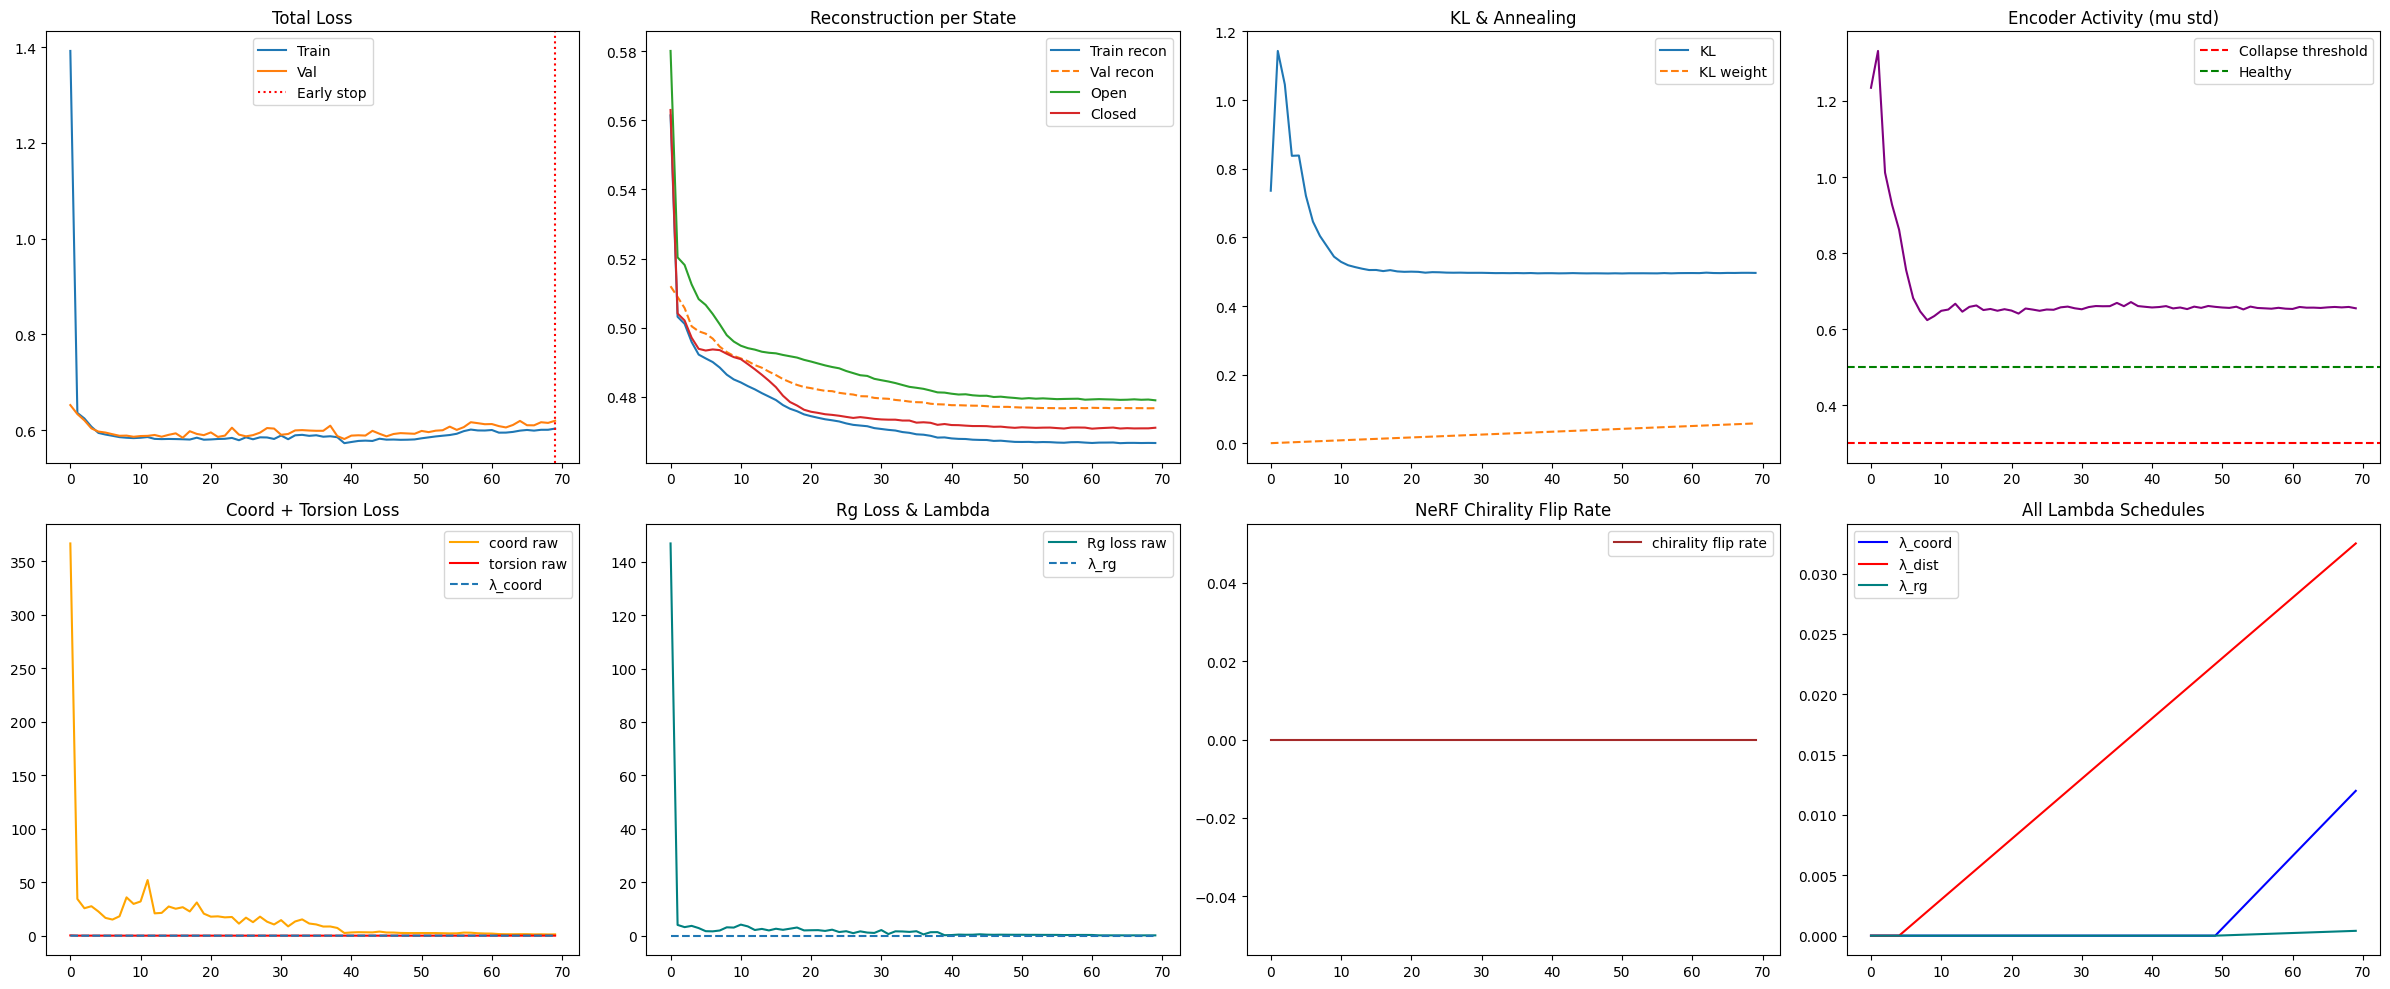

[SANITY 8] Encoder active (mu_std=0.6587): PASS
[SANITY 9] Best val loss finite (0.5817): PASS

Cell 9 complete


In [11]:
EPOCHS           = 300
LR               = 1e-4
KL_WARMUP        = 80
KL_SLOPE         = 0.06
FREE_BITS_EARLY  = 0.5
FREE_BITS_LATE   = 0.1
FREE_BITS_START  = 80
FREE_BITS_END    = 150
COLLAPSE_THR     = 0.05
ES_PATIENCE      = 30
ES_MIN_DELTA      = 1e-5

model     = ProteinCVAE().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20, min_lr=1e-6
)

history = {
    'train_total': [], 'val_total': [],
    'train_recon': [], 'val_recon': [],
    'train_kl':    [], 'kl_weight': [],
    'recon_open':  [], 'recon_closed': [],
    'mu_std':      [],
    'lambda_coord':[], 'lambda_dist': [], 'lambda_rg': [],
    'coord_raw':   [], 'dist_raw': [], 'rg_raw': [],
    'torsion_raw': [],
    'flip_rate':   [],
}

best_val_loss = float('inf')
es_counter    = 0
stopped_epoch = None


def kl_beta_schedule(epoch: int) -> float:
    warmup = int(EPOCHS * 0.4)
    return min(BETA_MAX, BETA_MAX * (epoch / max(warmup, 1)))


def get_free_bits(epoch: int) -> float:
    if epoch <= FREE_BITS_START:
        return FREE_BITS_EARLY
    if epoch >= FREE_BITS_END:
        return FREE_BITS_LATE
    t = (epoch - FREE_BITS_START) / (FREE_BITS_END - FREE_BITS_START)
    return FREE_BITS_EARLY + t * (FREE_BITS_LATE - FREE_BITS_END)


def run_epoch(loader, train, kl_weight, free_bits,
              lambda_coord, lambda_dist, lambda_rg):

    model.train() if train else model.eval()
    agg = {k: 0 for k in [
        'total','recon','kl','coord','rg','contact','dist','torsion',
        'recon_0','recon_1','n_0','n_1','flip_rate_sum','n_batches'
    ]}
    all_mu_list = []
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for x_batch, coords_batch, label_batch in loader:
            x_batch      = x_batch.to(DEVICE)
            coords_batch = coords_batch.to(DEVICE)
            label_batch  = label_batch.to(DEVICE)

            out = model(x_batch, label_batch, sample=True)
            if not train:
                all_mu_list.append(out['mu'].detach().cpu())

            b, a, d = decode_internal_coords(
                out['x_hat'], bond_mean_t, bond_std_t, angle_mean_t, angle_std_t
            )
            pred_ca, flip_rate = nerf_batch(b, a, d)

            losses = compute_total_loss(
                x=x_batch, x_hat=out['x_hat'],
                mu=out['mu'], log_var=out['log_var'],
                pred_coords=pred_ca, true_coords=coords_batch,
                labels_b=label_batch,
                kl_weight=kl_weight, free_bits=free_bits,
                lambda_coord=lambda_coord, lambda_dist=lambda_dist,
                lambda_rg=lambda_rg,
                contact_tgt=contact_tgt_t,
                mu_mat=mu_matrix, sigma_mat=sigma_matrix, pair_mask_t=pair_mask,
            )

            if train:
                optimizer.zero_grad()
                losses['total'].backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            B = x_batch.shape[0]
            for k_name in ['total','recon','kl','coord','rg','contact','dist','torsion']:
                agg[k_name] += losses[k_name].item() * B
            agg['flip_rate_sum'] += flip_rate
            agg['n_batches']     += 1
            for s in [0, 1]:
                mask = (label_batch == s)
                if mask.any():
                    agg[f'recon_{s}'] += F.mse_loss(
                        out['x_hat'][mask], x_batch[mask]
                    ).item() * mask.sum().item()
                    agg[f'n_{s}'] += mask.sum().item()

    n = len(loader.dataset)
    result = {k: agg[k] / n for k in ['total','recon','kl','coord','rg','contact','dist','torsion']}
    result['flip_rate'] = agg['flip_rate_sum'] / agg['n_batches']
    for s in [0, 1]:
        ns = agg[f'n_{s}']
        result[f'recon_{s}'] = agg[f'recon_{s}'] / ns if ns > 0 else 0.0
    if not train and all_mu_list:
        _all_mu = torch.cat(all_mu_list)
        result['mu_std']  = _all_mu.std().item()
        result['mu_mean'] = _all_mu.mean().item()
    else:
        result['mu_std']  = None
        result['mu_mean'] = None
    return result


print(f"{'Ep':>4} {'KL_w':>6} {'Tr':>8} {'Val':>8} {'KL':>8} "
      f"{'mu_std':>8} {'lam_c':>7} {'flip_r':>7} {'Open':>8} {'Closed':>8}")
print('-' * 100)

for epoch in range(1, EPOCHS + 1):
    kl_w   = kl_beta_schedule(epoch)
    fb     = get_free_bits(epoch)
    lam_c  = get_lambda_coord(epoch)
    lam_d  = get_lambda_dist(epoch)
    lam_rg = get_lambda_rg(epoch)

    tr_losses  = run_epoch(train_loader, True,  kl_w, fb, lam_c, lam_d, lam_rg)
    val_losses = run_epoch(val_loader,   False, kl_w, fb, lam_c, lam_d, lam_rg)
    scheduler.step(val_losses['total'])
    mu_std = val_losses['mu_std']

    for key, metric_val in [
        ('train_total',  tr_losses['total']),  ('val_total',    val_losses['total']),
        ('train_recon',  tr_losses['recon']),  ('val_recon',    val_losses['recon']),
        ('train_kl',     tr_losses['kl']),     ('kl_weight',    kl_w),
        ('recon_open',   tr_losses['recon_0']),('recon_closed', tr_losses['recon_1']),
        ('mu_std',       mu_std),
        ('lambda_coord', lam_c),               ('lambda_dist',  lam_d),
        ('lambda_rg',    lam_rg),
        ('coord_raw',    tr_losses['coord']),  ('dist_raw',     tr_losses['dist']),
        ('rg_raw',       tr_losses['rg']),
        ('torsion_raw',  tr_losses['torsion']),
        ('flip_rate',    tr_losses['flip_rate']),
    ]:
        history[key].append(metric_val)

    improved = val_losses['total'] < best_val_loss - ES_MIN_DELTA
    if improved:
        best_val_loss = val_losses['total']
        es_counter    = 0
        torch.save(model.state_dict(), CKPT_PATH)
        flag = ' ★'
    else:
        es_counter += 1
        flag = f' ({es_counter}/{ES_PATIENCE})'

    if mu_std is not None and mu_std < COLLAPSE_THR and epoch > 20:
        print(f'  COLLAPSE WARNING epoch {epoch}: mu_std={mu_std:.4f}')

    if epoch % 10 == 0 or epoch == 1:
        print(
            f'{epoch:4d} {kl_w:6.3f} {tr_losses["total"]:8.4f} {val_losses["total"]:8.4f} '
            f'{tr_losses["kl"]:8.4f} {mu_std if mu_std else 0:8.4f} {lam_c:7.4f} '
            f'{tr_losses["flip_rate"]:7.4f} '
            f'{tr_losses["recon_0"]:8.4f} {tr_losses["recon_1"]:8.4f}{flag}'
        )

    if es_counter >= ES_PATIENCE:
        stopped_epoch = epoch
        print(f'\n Early stopping at epoch {epoch}')
        break

if stopped_epoch is None:
    print(f'\nTraining complete ({EPOCHS} epochs). Best val: {best_val_loss:.4f}')
else:
    print(f'Training complete (stopped epoch {stopped_epoch}). Best val: {best_val_loss:.4f}')

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
print(f'Best checkpoint loaded from {CKPT_PATH}')

_fv = run_epoch(val_loader, False,
                kl_beta_schedule(EPOCHS), get_free_bits(EPOCHS),
                get_lambda_coord(EPOCHS), get_lambda_dist(EPOCHS), get_lambda_rg(EPOCHS))
final_mu_std  = _fv['mu_std']
final_mu_mean = _fv['mu_mean']
print(f'\nEncoder  mu_std={final_mu_std:.4f}  mu_mean={final_mu_mean:.4f}')
print('Active' if final_mu_std > 0.3 else 'Collapsed -- reduce BETA_MAX further')

fig, axes = plt.subplots(2, 4, figsize=(24, 10))

axes[0,0].plot(history['train_total'], label='Train')
axes[0,0].plot(history['val_total'],   label='Val')
if stopped_epoch:
    axes[0,0].axvline(stopped_epoch - 1, color='red', linestyle=':', label='Early stop')
axes[0,0].set_title('Total Loss'); axes[0,0].legend()

axes[0,1].plot(history['train_recon'],  label='Train recon')
axes[0,1].plot(history['val_recon'],    label='Val recon', linestyle='--')
axes[0,1].plot(history['recon_open'],   label='Open')
axes[0,1].plot(history['recon_closed'], label='Closed')
axes[0,1].set_title('Reconstruction per State'); axes[0,1].legend()

axes[0,2].plot(history['train_kl'],  label='KL')
axes[0,2].plot(history['kl_weight'], label='KL weight', linestyle='--')
axes[0,2].set_title('KL & Annealing'); axes[0,2].legend()

axes[0,3].plot(history['mu_std'], color='purple')
axes[0,3].axhline(0.3, color='red',   linestyle='--', label='Collapse threshold')
axes[0,3].axhline(0.5, color='green', linestyle='--', label='Healthy')
axes[0,3].set_title('Encoder Activity (mu std)'); axes[0,3].legend()

axes[1,0].plot(history['coord_raw'],    label='coord raw',    color='orange')
axes[1,0].plot(history['torsion_raw'],  label='torsion raw',  color='red')
axes[1,0].plot(history['lambda_coord'], label='λ_coord',      linestyle='--')
axes[1,0].set_title('Coord + Torsion Loss'); axes[1,0].legend()

axes[1,1].plot(history['rg_raw'],    label='Rg loss raw', color='teal')
axes[1,1].plot(history['lambda_rg'], label='λ_rg',        linestyle='--')
axes[1,1].set_title('Rg Loss & Lambda'); axes[1,1].legend()

axes[1,2].plot(history['flip_rate'], color='brown', label='chirality flip rate')
axes[1,2].set_title('NeRF Chirality Flip Rate'); axes[1,2].legend()

axes[1,3].plot(history['lambda_coord'], label='λ_coord', color='blue')
axes[1,3].plot(history['lambda_dist'],  label='λ_dist',  color='red')
axes[1,3].plot(history['lambda_rg'],    label='λ_rg',    color='teal')
axes[1,3].set_title('All Lambda Schedules'); axes[1,3].legend()

plt.tight_layout()
plt.savefig(f'{DRIVE}/training_curves_v5.png', dpi=150)
plt.show()

assert final_mu_std is not None and final_mu_std > COLLAPSE_THR, \
    f'SANITY 8 FAIL: encoder collapsed (mu_std={final_mu_std:.4f})'
print(f'[SANITY 8] Encoder active (mu_std={final_mu_std:.4f}): PASS')

assert float(best_val_loss) < float('inf') and math.isfinite(float(best_val_loss))
print(f'[SANITY 9] Best val loss finite ({best_val_loss:.4f}): PASS')
print('\nCell 9 complete')

### Generation & Evaluation

In [12]:
N_GEN = 500

train_idx_set = set(train_idx.tolist())


def compute_aggregate_posterior(model, loader, device):
    """Returns per-dim (latent_mean, latent_std) using law of total variance."""
    all_mu, all_lv = [], []
    model.eval()
    with torch.no_grad():
        for xb, _, lb in loader:
            mu, lv = model.encode(xb.to(device), lb.to(device))
            all_mu.append(mu.cpu())
            all_lv.append(lv.cpu())
    all_mu = torch.cat(all_mu)
    all_lv = torch.cat(all_lv)
    latent_mean = all_mu.mean(0)
    latent_std  = (all_mu.var(0) + all_lv.exp().mean(0)).sqrt()
    print(f'  Aggregate posterior — '
          f'mean norm: {latent_mean.norm():.3f}  '
          f'std mean: {latent_std.mean():.3f}  '
          f'std range: [{latent_std.min():.3f}, {latent_std.max():.3f}]')
    return latent_mean, latent_std

print('Computing aggregate posterior stats from training set...')
_agg_mean, _agg_std = compute_aggregate_posterior(model, train_loader, DEVICE)


def generate_state(
    state_label:
        int,
    n_samples:
        int,
    temperature: float = 0.8,
    use_posterior: bool  = True,
) -> torch.Tensor:

    model.eval()

    if use_posterior:
        train_state_mask = np.array([
            i for i in train_idx if labels[i] == state_label
        ])
        if len(train_state_mask) == 0:
            raise ValueError(f'No training frames for state {state_label}')

        X_s = torch.tensor(X[train_state_mask],           dtype=torch.float32)
        C_s = torch.tensor(coords_all[train_state_mask],  dtype=torch.float32)
        L_s = torch.tensor(labels[train_state_mask],      dtype=torch.long)

        all_mu, all_lv = [], []
        with torch.no_grad():
            dl = DataLoader(
                torch.utils.data.TensorDataset(X_s, C_s, L_s),
                batch_size=128, shuffle=False,
            )
            for xb, _, lb in dl:
                mu, lv = model.encode(xb.to(DEVICE), lb.to(DEVICE))
                all_mu.append(mu.cpu())
                all_lv.append(lv.cpu())

        all_mu = torch.cat(all_mu)
        all_lv = torch.cat(all_lv)
        print(f'  State {state_label}: {len(all_mu)} train frames in posterior')

        idx  = torch.randint(0, len(all_mu), (n_samples,))
        mu_s = all_mu[idx].to(DEVICE)
        lv_s = all_lv[idx].to(DEVICE)
        z    = mu_s + temperature * torch.exp(0.5 * lv_s) * torch.randn_like(mu_s)

    else:
        z = (
            _agg_mean.to(DEVICE)
            + temperature * _agg_std.to(DEVICE) * torch.randn(n_samples, LATENT_DIM, device=DEVICE)
        )

    label = torch.full((n_samples,), state_label, dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        x_hat         = model.decode(z, label)
        b, a, d       = decode_internal_coords(
            x_hat, bond_mean_t, bond_std_t, angle_mean_t, angle_std_t
        )
        coords, _     = nerf_batch(b, a, d)

    ref_t          = torch.tensor(global_ref, dtype=torch.float32, device=DEVICE)
    coords, _      = kabsch_align_torch(ref_t, coords)
    return coords.cpu()


def write_pdb_multimodel(coords_np, topology, output_path):
    if topology is None:
        raise ValueError('topology is None — cannot write PDB')
    traj = md.Trajectory(xyz=coords_np / 10.0, topology=topology)
    traj.save_pdb(output_path)
    print(f'  Saved {len(traj)} models → {output_path}')


print(f'\nGenerating {N_GEN} structures per state (prior sampling, T=1.0)...')
gen_open   = generate_state(0, N_GEN, temperature=0.6, use_posterior=False)
gen_closed = generate_state(1, N_GEN, temperature=1.0, use_posterior=False)

print(f'\nGenerated open   : {gen_open.shape}')
print(f'Generated closed : {gen_closed.shape}')

for name, gen in [('open', gen_open), ('closed', gen_closed)]:
    std = gen.std(0).mean().item()
    flag = '  ✓' if std >= 1.0 else '  ⚠ Low — check KL collapse or temperature'
    print(f'  Diversity ({name}) : mean per-dim std = {std:.3f} Å{flag}')

write_pdb_multimodel(gen_open.numpy(),   ca_topology, f'{DRIVE}/generated_open_prior.pdb')
write_pdb_multimodel(gen_closed.numpy(), ca_topology, f'{DRIVE}/generated_closed_prior.pdb')

Computing aggregate posterior stats from training set...
  Aggregate posterior — mean norm: 1.129  std mean: 0.853  std range: [0.662, 0.941]

Generating 500 structures per state (prior sampling, T=1.0)...

Generated open   : torch.Size([500, 341, 3])
Generated closed : torch.Size([500, 341, 3])
  Diversity (open) : mean per-dim std = 0.829 Å  ⚠ Low — check KL collapse or temperature
  Diversity (closed) : mean per-dim std = 0.548 Å  ⚠ Low — check KL collapse or temperature
  Saved 500 models → /content/drive/MyDrive/generated_open_prior.pdb
  Saved 500 models → /content/drive/MyDrive/generated_closed_prior.pdb


### RMSD & Dihedral Plots

Test set: open=285  closed=288
Computing RMSD vs TEST set...


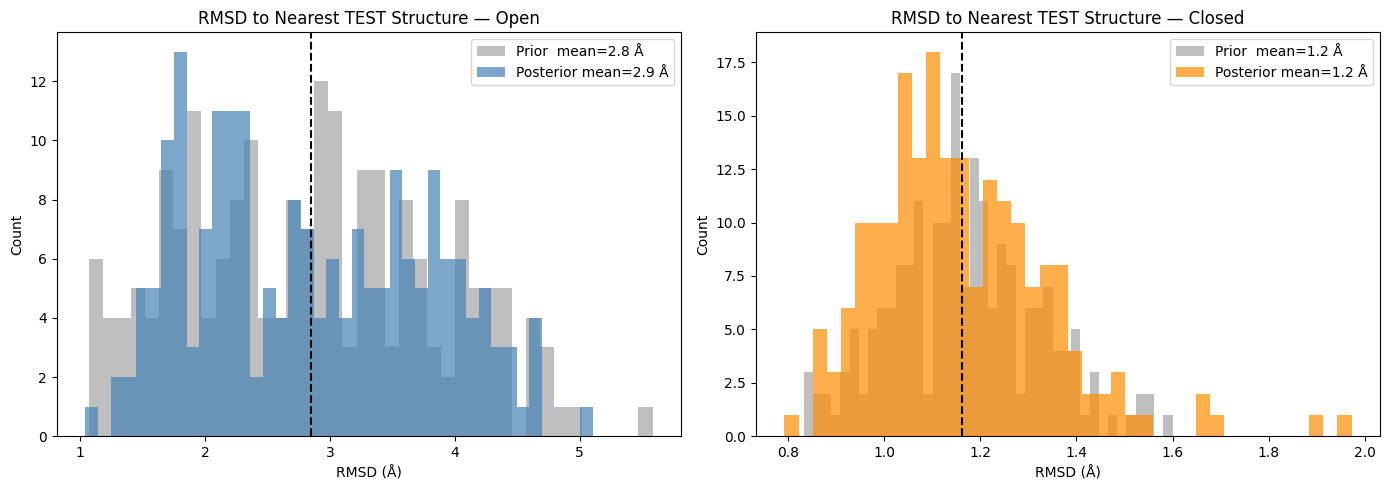


Cα Pseudo-Dihedral Plot (NOT Ramachandran)...


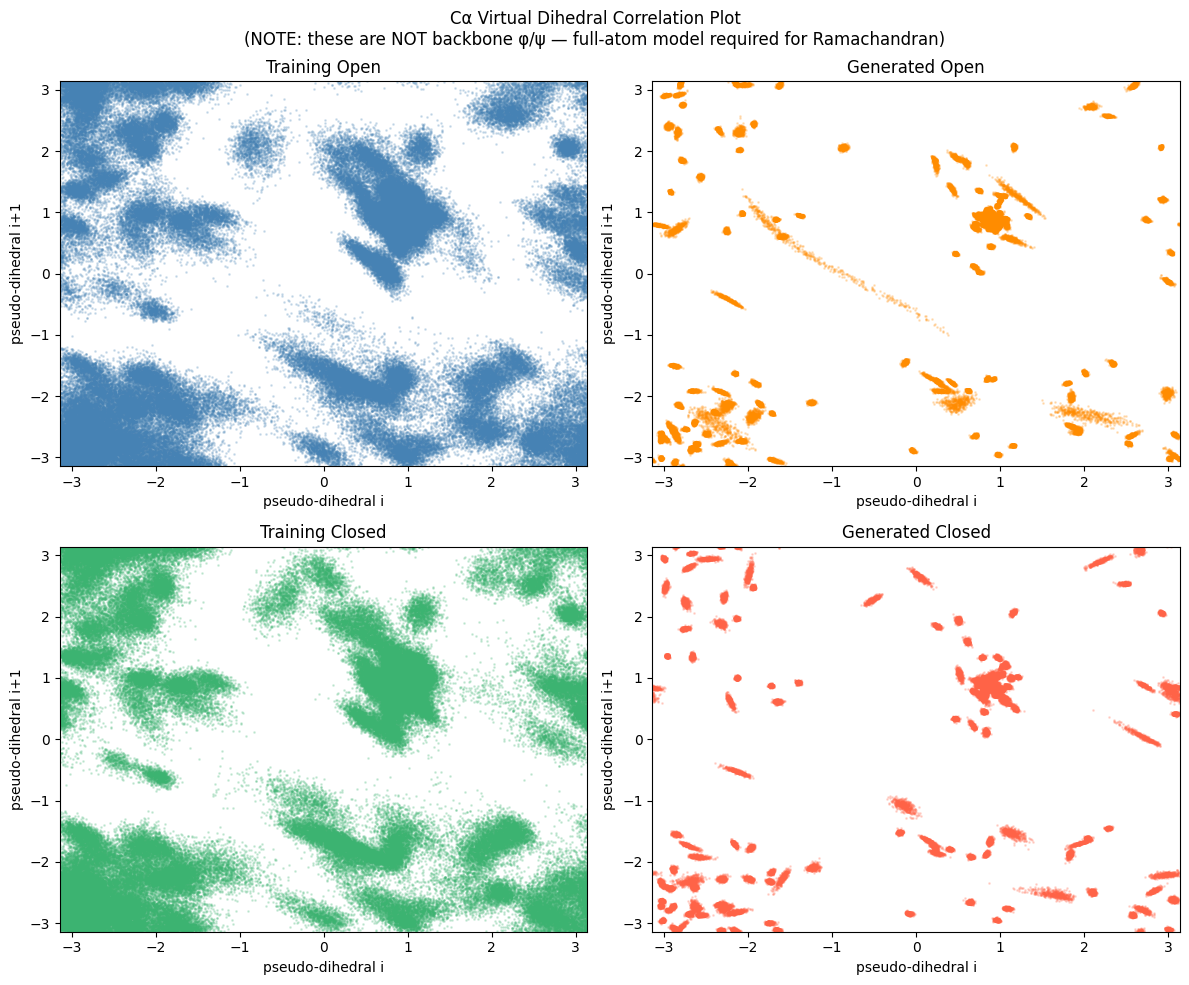


Radius of Gyration...
  Open   — test: 23.81±0.29  gen: 24.24±0.23 Å  target: 23.80 Å
  Closed — test: 22.96±0.32  gen: 22.88±0.17 Å  target: 22.94 Å


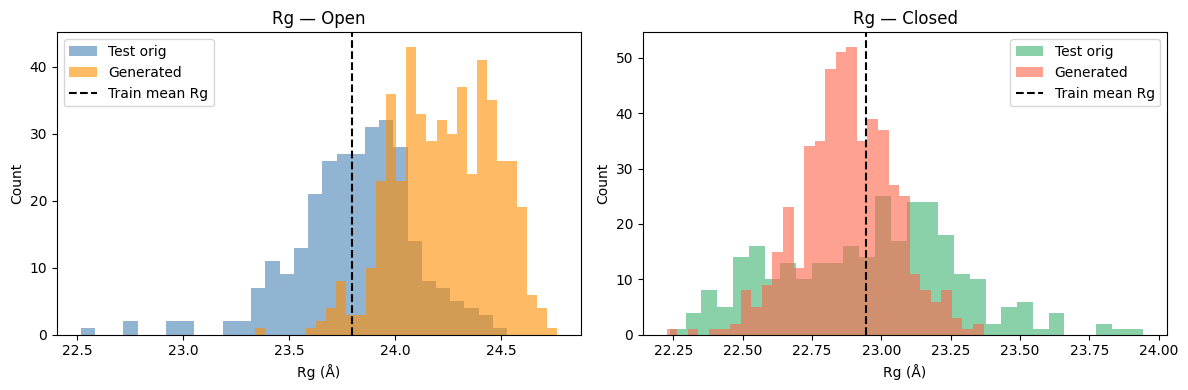


Contact map F1 (vs TEST set)...
    contact_f1 open: N_gen=285  N_orig=285
    contact_f1 closed: N_gen=288  N_orig=288
  F1 open   : 0.9418
  F1 closed : 0.9848
  F1 macro  : 0.9633


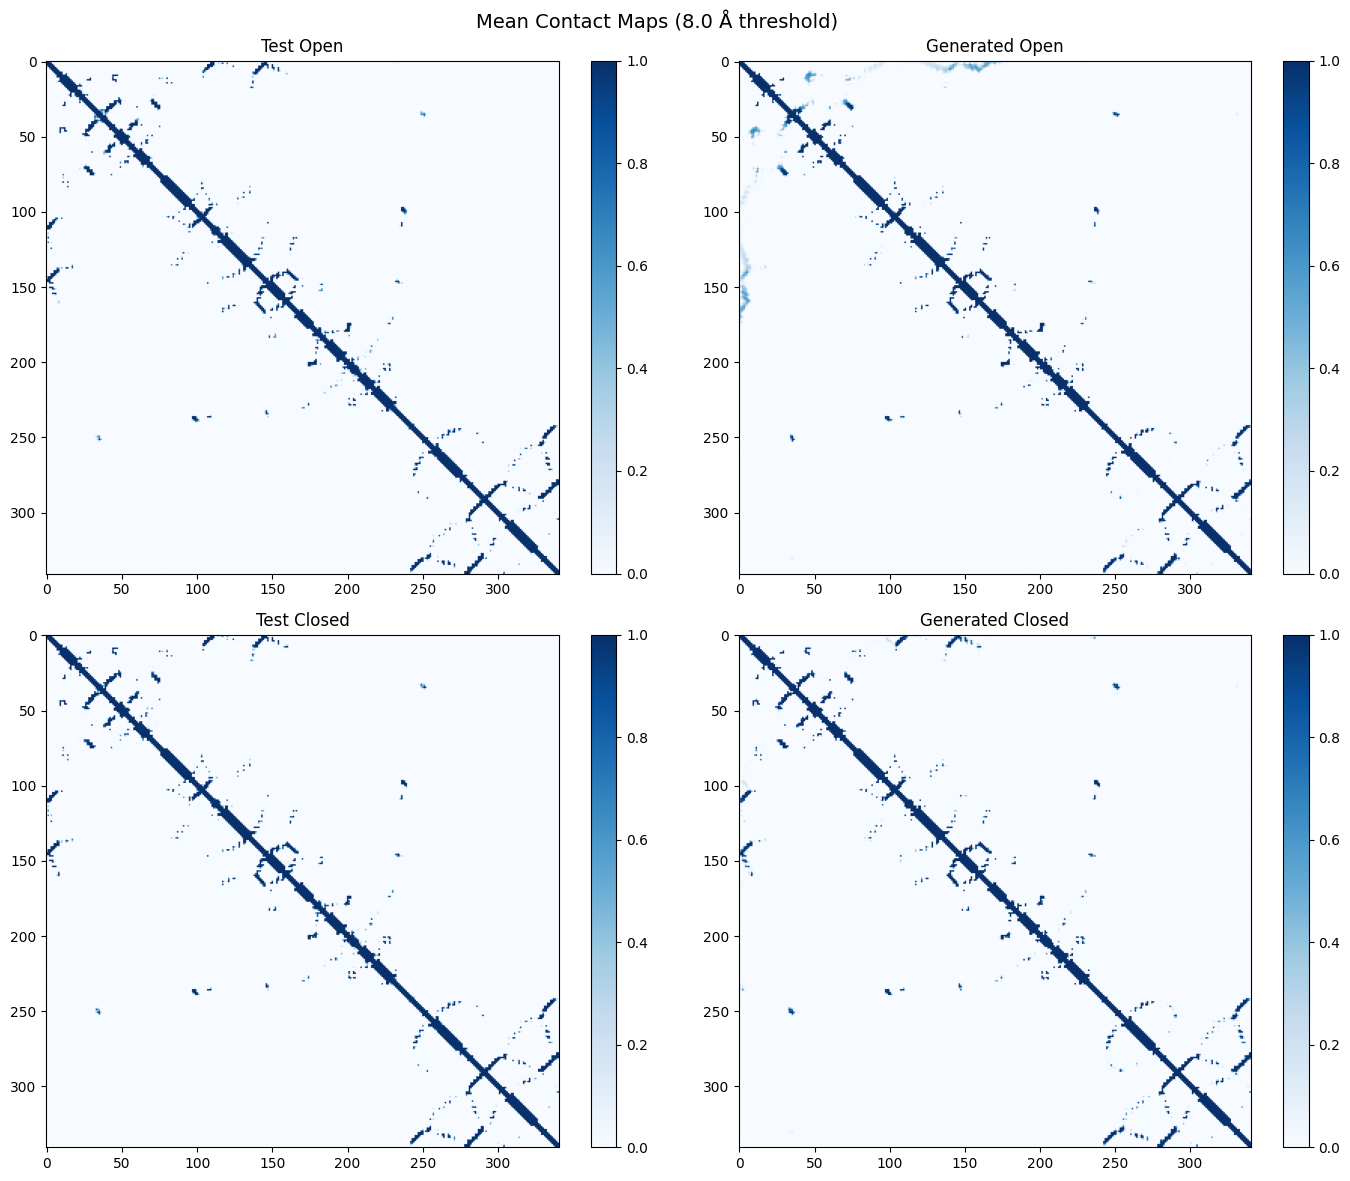


Structure overlays...


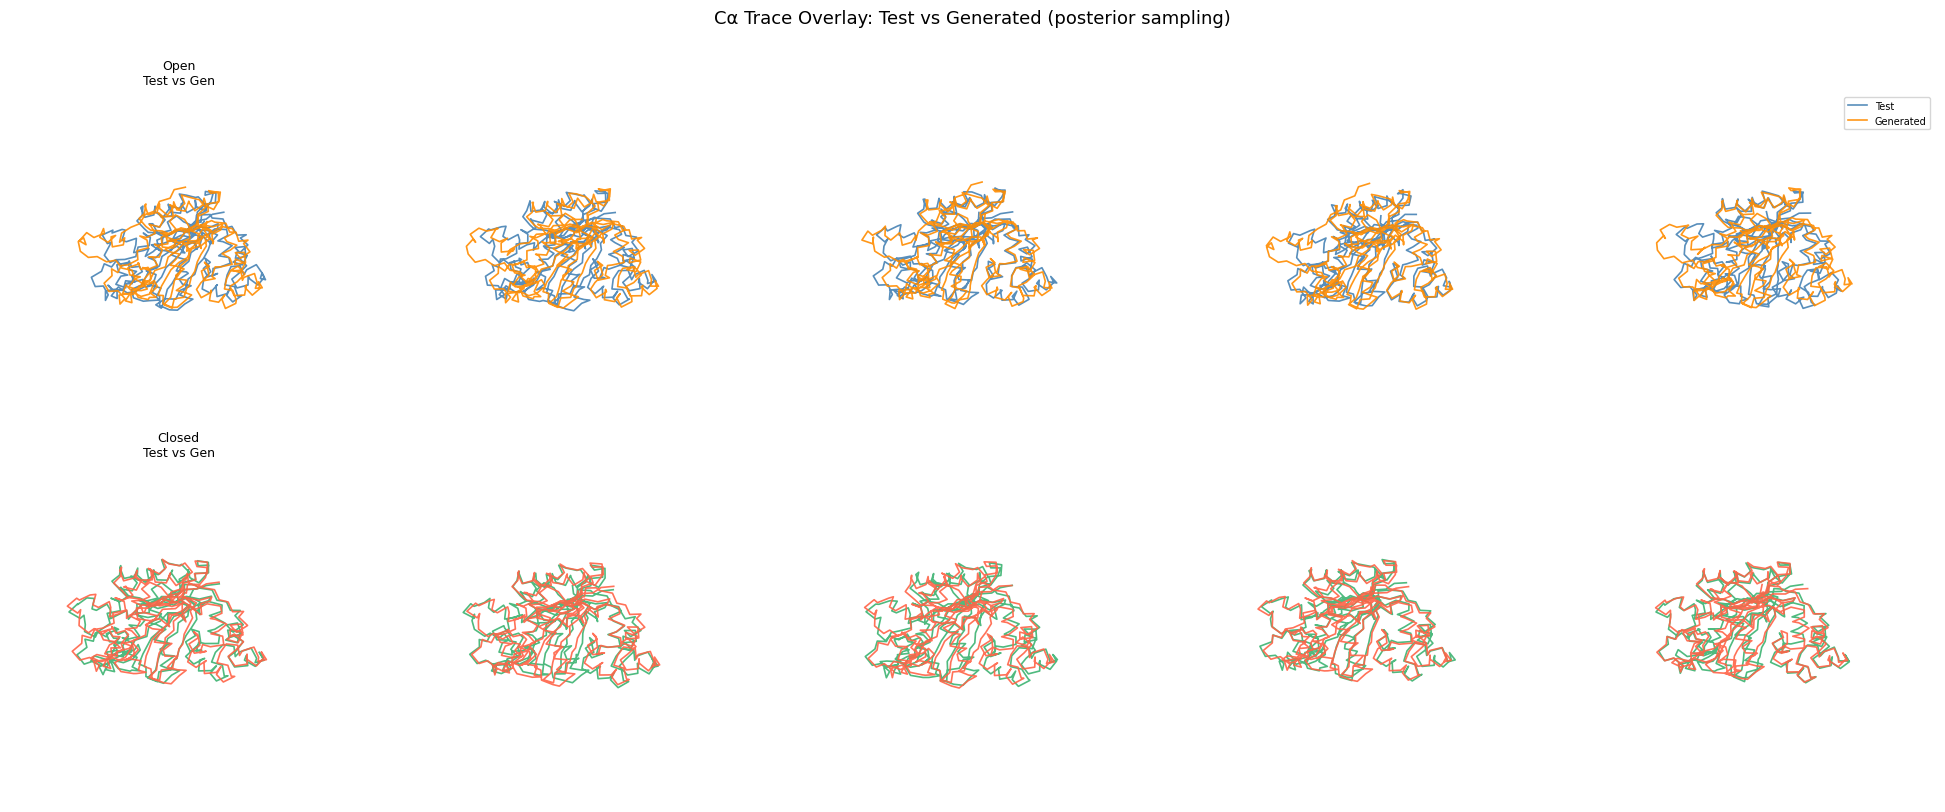


EVALUATION SUMMARY  (metrics vs held-out TEST set)
Metric                                    Open     Closed
------------------------------------------------------------
RMSD posterior (Å)                        2.85       1.16
RMSD prior (Å)                            2.84       1.17
Rg mean generated (Å)                    24.24      22.88
Rg mean test (Å)                         23.81      22.96
Rg std generated (Å)                      0.23       0.17
Contact F1 (vs test)                    0.9418     0.9848
Encoder mu_std                          0.6587   (shared)
Training stopped at                               epoch 70

 All evaluation figures saved to Drive.


In [13]:
def compute_rmsd_to_nearest(gen: np.ndarray, orig: np.ndarray) -> np.ndarray:
    rmsds = []
    for g in gen:
        diffs = orig - g[None]
        r     = np.sqrt((diffs**2).sum(-1).mean(-1))
        rmsds.append(r.min())
    return np.array(rmsds)


def radius_of_gyration(coords: np.ndarray) -> np.ndarray:
    centres = coords.mean(axis=1, keepdims=True)
    return np.sqrt(((coords - centres)**2).sum(-1).mean(-1))


def contact_f1(gen, orig, threshold=CONTACT_THR, tag=''):
    """Now prints N used (gen and orig) so metric variance is interpretable."""
    def mean_cm(ca):
        cms = []
        for f in ca:
            d = np.linalg.norm(f[:, None] - f[None, :], axis=-1)
            cms.append((d < threshold).astype(float))
        return np.array(cms).mean(0)
    n_gen = len(gen); n_orig = len(orig)
    print(f'    contact_f1 {tag}: N_gen={n_gen}  N_orig={n_orig}')
    cm_gen  = (mean_cm(gen)  > 0.5).astype(int).ravel()
    cm_orig = (mean_cm(orig) > 0.5).astype(int).ravel()
    return f1_score(cm_orig, cm_gen, zero_division=0)


def ca_pseudo_dihedrals(ca: np.ndarray) -> np.ndarray:
    """Cα virtual dihedrals (NOT backbone φ/ψ)."""
    b1 = ca[:, 1:-2] - ca[:, :-3]
    b2 = ca[:, 2:-1] - ca[:, 1:-2]
    b3 = ca[:, 3:]   - ca[:, 2:-1]
    n1 = np.cross(b1, b2); n1 /= (np.linalg.norm(n1, axis=-1, keepdims=True) + EPS)
    n2 = np.cross(b2, b3); n2 /= (np.linalg.norm(n2, axis=-1, keepdims=True) + EPS)
    b2u = b2 / (np.linalg.norm(b2, axis=-1, keepdims=True) + EPS)
    return np.arctan2((np.cross(n1, n2) * b2u).sum(-1), (n1 * n2).sum(-1))


orig_open   = coords_test[labels_test == 0]
orig_closed = coords_test[labels_test == 1]
train_open   = coords_train[labels_train == 0]
train_closed = coords_train[labels_train == 1]
gen_open_np   = gen_open.numpy()
gen_closed_np = gen_closed.numpy()

print(f'Test set: open={len(orig_open)}  closed={len(orig_closed)}')

print('Computing RMSD vs TEST set...')
gen_open_prior   = generate_state(0, 200, temperature=1.0, use_posterior=False)
gen_closed_prior = generate_state(1, 200, temperature=1.0, use_posterior=False)

rmsd_open_post   = compute_rmsd_to_nearest(gen_open_np[:200],        orig_open)
rmsd_open_prior  = compute_rmsd_to_nearest(gen_open_prior.numpy(),   orig_open)
rmsd_closed_post = compute_rmsd_to_nearest(gen_closed_np[:200],      orig_closed)
rmsd_closed_prior= compute_rmsd_to_nearest(gen_closed_prior.numpy(), orig_closed)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (r_post, r_prior, title) in zip(axes, [
    (rmsd_open_post,   rmsd_open_prior,   'Open'),
    (rmsd_closed_post, rmsd_closed_prior, 'Closed'),
]):
    ax.hist(r_prior, bins=40, alpha=0.5, color='grey',
            label=f'Prior  mean={r_prior.mean():.1f} Å')
    ax.hist(r_post,  bins=40, alpha=0.7,
            color='steelblue' if title=='Open' else 'darkorange',
            label=f'Posterior mean={r_post.mean():.1f} Å')
    ax.axvline(r_post.mean(), linestyle='--', color='black')
    ax.set_title(f'RMSD to Nearest TEST Structure — {title}')
    ax.set_xlabel('RMSD (Å)'); ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.savefig(f'{DRIVE}/eval_rmsd_v5.png', dpi=150)
plt.show()

print('\nCα Pseudo-Dihedral Plot (NOT Ramachandran)...')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
pairs = [
    (train_open,    'Training Open',     'steelblue'),
    (gen_open_np,   'Generated Open',    'darkorange'),
    (train_closed,  'Training Closed',   'mediumseagreen'),
    (gen_closed_np, 'Generated Closed',  'tomato'),
]
for ax, (ca, title, col) in zip(axes.flat, pairs):
    d   = ca_pseudo_dihedrals(ca).ravel()
    phi = d[0::2]; psi = d[1::2]
    mn  = min(len(phi), len(psi))
    ax.scatter(phi[:mn], psi[:mn], s=1, alpha=0.2, color=col)
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(-np.pi, np.pi)
    ax.set_xlabel('pseudo-dihedral i'); ax.set_ylabel('pseudo-dihedral i+1')
    ax.set_title(title)
plt.suptitle('Cα Virtual Dihedral Correlation Plot\n'
             '(NOTE: these are NOT backbone φ/ψ — full-atom model required for Ramachandran)',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE}/eval_ca_dihedrals_v5.png', dpi=150)
plt.show()

print('\nRadius of Gyration...')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (gen, orig, title, co, cg) in zip(axes, [
    (gen_open_np,   orig_open,   'Open',   'steelblue',      'darkorange'),
    (gen_closed_np, orig_closed, 'Closed', 'mediumseagreen', 'tomato'),
]):
    rg_o = radius_of_gyration(orig)
    rg_g = radius_of_gyration(gen)
    ax.hist(rg_o, bins=30, alpha=0.6, label='Test orig',  color=co)
    ax.hist(rg_g, bins=30, alpha=0.6, label='Generated',  color=cg)
    ax.axvline(RG_TARGET[0 if title=='Open' else 1].item(),
               color='black', linestyle='--', label='Train mean Rg')
    ax.set_title(f'Rg — {title}')
    ax.set_xlabel('Rg (Å)'); ax.set_ylabel('Count')
    ax.legend()
    print(f'  {title:6s} — test: {rg_o.mean():.2f}±{rg_o.std():.2f}  '
          f'gen: {rg_g.mean():.2f}±{rg_g.std():.2f} Å  '
          f'target: {RG_TARGET[0 if title=="Open" else 1].item():.2f} Å')
plt.tight_layout()
plt.savefig(f'{DRIVE}/eval_rg_v5.png', dpi=150)
plt.show()

# Calculate Rg for generated structures for the summary table
rg_open_gen = radius_of_gyration(gen_open_np)
rg_closed_gen = radius_of_gyration(gen_closed_np)

print('\nContact map F1 (vs TEST set)...')
f1_open   = contact_f1(gen_open_np[:len(orig_open)],     orig_open,   tag='open')
f1_closed = contact_f1(gen_closed_np[:len(orig_closed)], orig_closed, tag='closed')
print(f'  F1 open   : {f1_open:.4f}')
print(f'  F1 closed : {f1_closed:.4f}')
print(f'  F1 macro  : {(f1_open+f1_closed)/2:.4f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
titles = ['Test Open','Generated Open','Test Closed','Generated Closed']
arrs   = [orig_open[:100], gen_open_np[:100], orig_closed[:100], gen_closed_np[:100]]
for ax, title, ca_arr in zip(axes.flat, titles, arrs):
    cms = []
    for f in ca_arr:
        d = np.linalg.norm(f[:, None] - f[None, :], axis=-1)
        cms.append((d < CONTACT_THR).astype(float))
    im = ax.imshow(np.array(cms).mean(0), cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title); plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f'Mean Contact Maps ({CONTACT_THR} Å threshold)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{DRIVE}/eval_contact_maps_v5.png', dpi=150)
plt.show()

print('\nStructure overlays...')
fig = plt.figure(figsize=(20, 8))
for row, (orig, gen, state_name, col_o, col_g) in enumerate([
    (orig_open,   gen_open_np,   'Open',   'steelblue',     'darkorange'),
    (orig_closed, gen_closed_np, 'Closed', 'mediumseagreen', 'tomato'),
]):
    o_idx = np.random.choice(len(orig), min(5, len(orig)), replace=False)
    g_idx = np.random.choice(len(gen),  5, replace=False)
    for col, (io, ig) in enumerate(zip(o_idx, g_idx)):
        ax = fig.add_subplot(2, 5, row*5+col+1, projection='3d')
        o  = orig[io]; g = gen[ig]
        ax.plot(o[:,0], o[:,1], o[:,2], color=col_o, lw=1.2, alpha=0.9, label='Test')
        ax.plot(g[:,0], g[:,1], g[:,2], color=col_g, lw=1.2, alpha=0.9, label='Generated')
        ax.set_axis_off()
        if col == 0: ax.set_title(f'{state_name}\nTest vs Gen', fontsize=9)
        if row == 0 and col == 4: ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Cα Trace Overlay: Test vs Generated (posterior sampling)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{DRIVE}/eval_overlay_v5.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print('EVALUATION SUMMARY  (metrics vs held-out TEST set)')
print('='*60)
print(f'{"Metric":<35} {"Open":>10} {"Closed":>10}')
print('-'*60)
print(f'{"RMSD posterior (Å)":<35} {rmsd_open_post.mean():>10.2f} {rmsd_closed_post.mean():>10.2f}')
print(f'{"RMSD prior (Å)":<35} {rmsd_open_prior.mean():>10.2f} {rmsd_closed_prior.mean():>10.2f}')
print(f'{"Rg mean generated (Å)":<35} {rg_open_gen.mean():>10.2f} {rg_closed_gen.mean():>10.2f}')
print(f'{"Rg mean test (Å)":<35} {radius_of_gyration(orig_open).mean():>10.2f} {radius_of_gyration(orig_closed).mean():>10.2f}')
print(f'{"Rg std generated (Å)":<35} {rg_open_gen.std():>10.2f} {rg_closed_gen.std():>10.2f}')
print(f'{"Contact F1 (vs test)":<35} {f1_open:>10.4f} {f1_closed:>10.4f}')
print(f'{"Encoder mu_std":<35} {final_mu_std:>10.4f} {"(shared)":>10}')
stop_info = f'epoch {stopped_epoch}' if stopped_epoch else f'{EPOCHS} epochs'
print(f'{"Training stopped at":<35} {stop_info:>22}')
print('='*60)
print('\n All evaluation figures saved to Drive.')

### Internal Coordinate Distributions


Internal Coordinate Distributions...


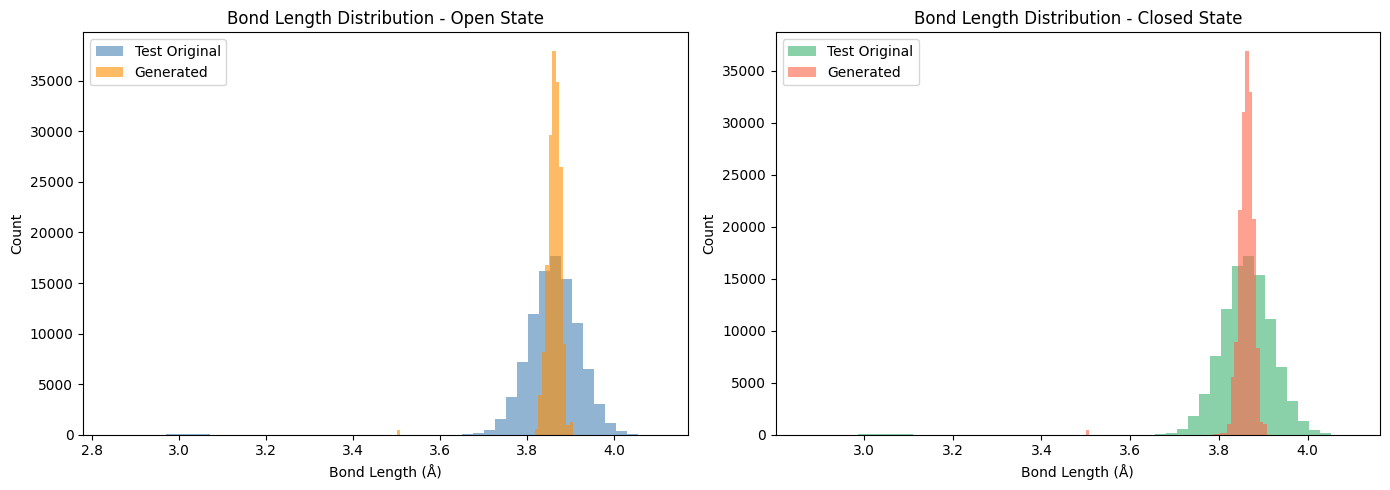

In [14]:

print('\nInternal Coordinate Distributions...')

# Bond Length Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Open State Bonds
bonds_open_orig = np.array([compute_bonds(f) for f in orig_open]).ravel()
bonds_open_gen = np.array([compute_bonds(f) for f in gen_open_np]).ravel()
axes[0].hist(bonds_open_orig, bins=50, alpha=0.6, label='Test Original', color='steelblue')
axes[0].hist(bonds_open_gen, bins=50, alpha=0.6, label='Generated', color='darkorange')
axes[0].set_title('Bond Length Distribution - Open State')
axes[0].set_xlabel('Bond Length (Å)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Closed State Bonds
bonds_closed_orig = np.array([compute_bonds(f) for f in orig_closed]).ravel()
bonds_closed_gen = np.array([compute_bonds(f) for f in gen_closed_np]).ravel()
axes[1].hist(bonds_closed_orig, bins=50, alpha=0.6, label='Test Original', color='mediumseagreen')
axes[1].hist(bonds_closed_gen, bins=50, alpha=0.6, label='Generated', color='tomato')
axes[1].set_title('Bond Length Distribution - Closed State')
axes[1].set_xlabel('Bond Length (Å)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{DRIVE}/eval_bond_distributions_v5.png', dpi=150)
plt.show()

### Bond Angle Distributions

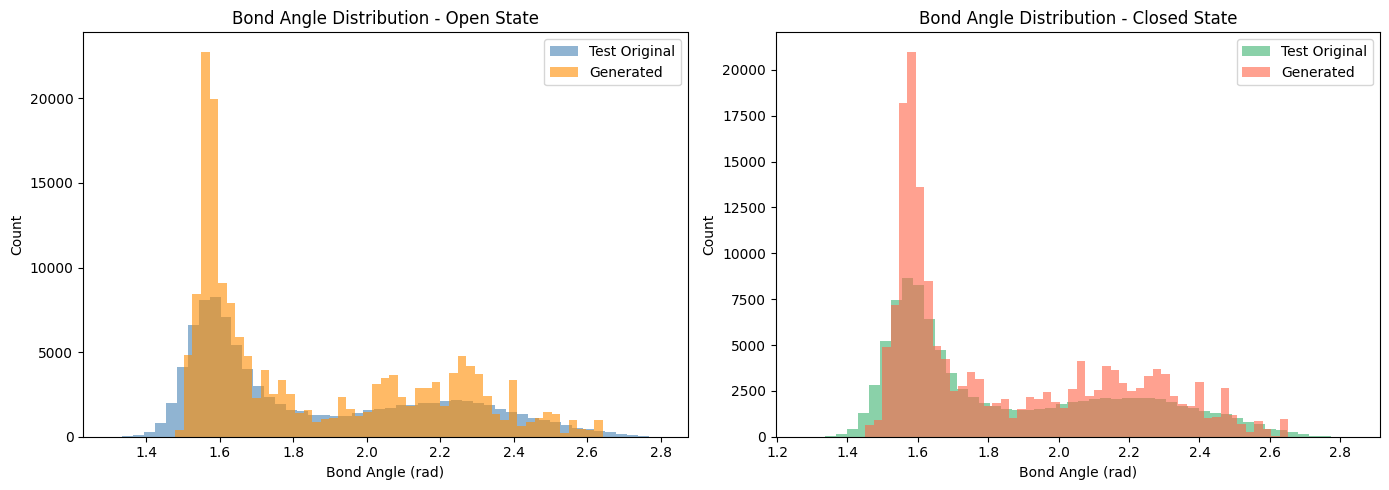

In [15]:
# Bond Angle Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Open State Angles
angles_open_orig = np.array([compute_angles(f) for f in orig_open]).ravel()
angles_open_gen = np.array([compute_angles(f) for f in gen_open_np]).ravel()
axes[0].hist(angles_open_orig, bins=50, alpha=0.6, label='Test Original', color='steelblue')
axes[0].hist(angles_open_gen, bins=50, alpha=0.6, label='Generated', color='darkorange')
axes[0].set_title('Bond Angle Distribution - Open State')
axes[0].set_xlabel('Bond Angle (rad)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Closed State Angles
angles_closed_orig = np.array([compute_angles(f) for f in orig_closed]).ravel()
angles_closed_gen = np.array([compute_angles(f) for f in gen_closed_np]).ravel()
axes[1].hist(angles_closed_orig, bins=50, alpha=0.6, label='Test Original', color='mediumseagreen')
axes[1].hist(angles_closed_gen, bins=50, alpha=0.6, label='Generated', color='tomato')
axes[1].set_title('Bond Angle Distribution - Closed State')
axes[1].set_xlabel('Bond Angle (rad)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{DRIVE}/eval_angle_distributions_v5.png', dpi=150)
plt.show()

### Dihedral Distributions

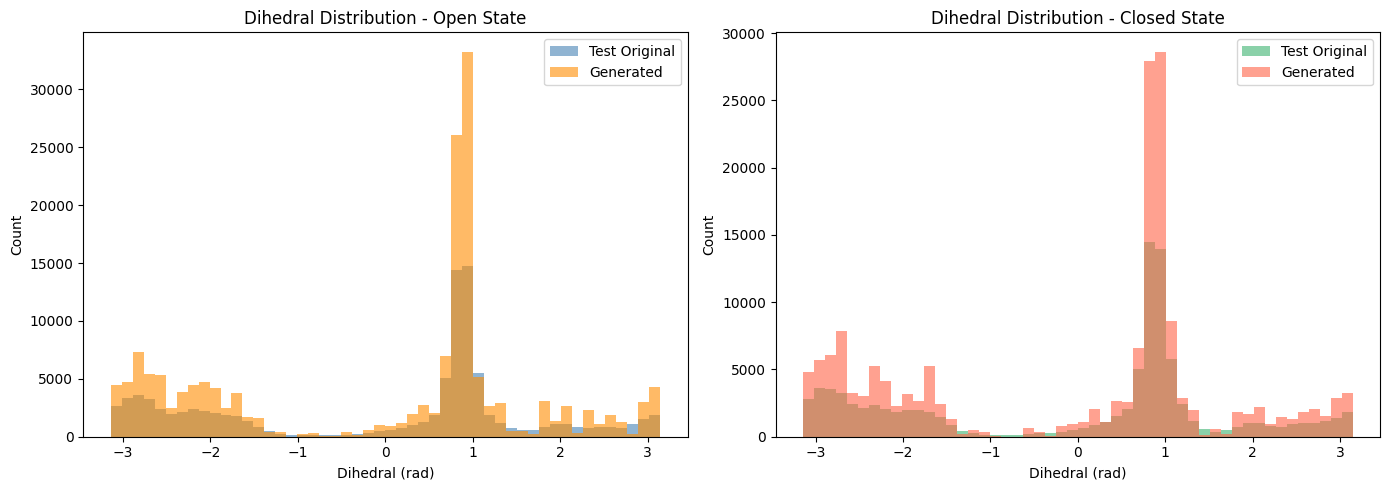

In [16]:

# Dihedral Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Open State Dihedrals
dihedrals_open_orig = compute_dihedrals_batch(orig_open).ravel()
dihedrals_open_gen = compute_dihedrals_batch(gen_open_np).ravel()
axes[0].hist(dihedrals_open_orig, bins=50, alpha=0.6, label='Test Original', color='steelblue')
axes[0].hist(dihedrals_open_gen, bins=50, alpha=0.6, label='Generated', color='darkorange')
axes[0].set_title('Dihedral Distribution - Open State')
axes[0].set_xlabel('Dihedral (rad)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Closed State Dihedrals
dihedrals_closed_orig = compute_dihedrals_batch(orig_closed).ravel()
dihedrals_closed_gen = compute_dihedrals_batch(gen_closed_np).ravel()
axes[1].hist(dihedrals_closed_orig, bins=50, alpha=0.6, label='Test Original', color='mediumseagreen')
axes[1].hist(dihedrals_closed_gen, bins=50, alpha=0.6, label='Generated', color='tomato')
axes[1].set_title('Dihedral Distribution - Closed State')
axes[1].set_xlabel('Dihedral (rad)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{DRIVE}/eval_dihedral_distributions_v5.png', dpi=150)
plt.show()
